<Axes: title={'center': 'Apple - Raw Close Prices for SARIMA'}, xlabel='Date'>

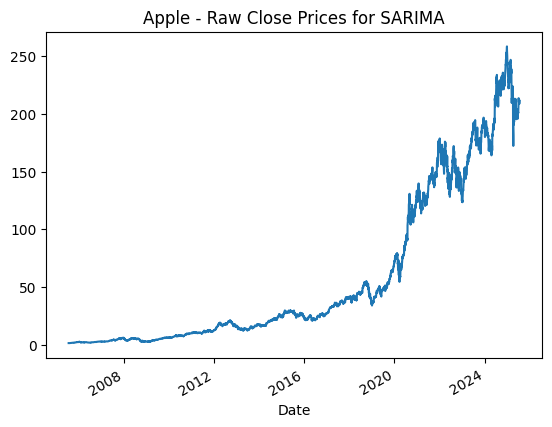

In [3]:
# Preprocessing for SARIMA with raw Close prices
import pandas as pd

# Load data
df = pd.read_csv("../Data/EDA_transformed.csv")  # replace with your actual file path
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# Filter for one stock at a time (example: Apple)
apple_df = df[df['Stocks'] == 'Apple']
ts = apple_df['Close']

# Check for missing values
ts = ts.dropna()

# Plot to inspect
ts.plot(title="Apple - Raw Close Prices for SARIMA")


In [4]:
from statsmodels.tsa.stattools import adfuller

# Run ADF test
adf_result = adfuller(ts)

# Display results
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

# Interpretation
if adf_result[1] <= 0.05:
    print("✅ The data is stationary (p <= 0.05)")
else:
    print("❌ The data is non-stationary (p > 0.05)")


ADF Statistic: 0.9034734300303623
p-value: 0.9931354885165544
Critical Values:
   1%: -3.43165984259144
   5%: -2.8621188086591505
   10%: -2.5670781005730454
❌ The data is non-stationary (p > 0.05)


<Figure size 1200x800 with 0 Axes>

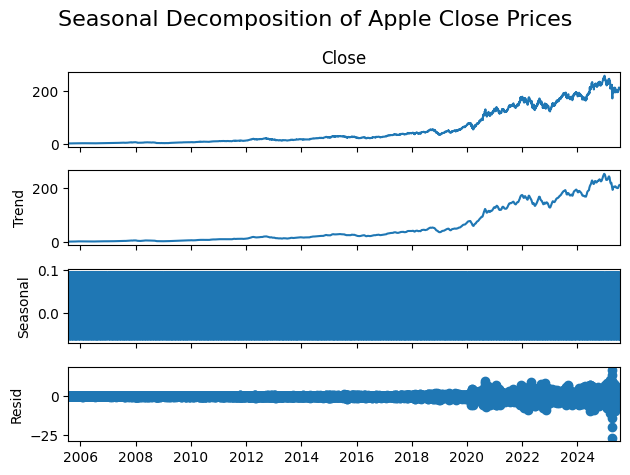

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Decompose the time series
decomposition = seasonal_decompose(ts, model='additive', period=12)  # Assuming monthly data

# Plot the decomposition
plt.figure(figsize=(12, 8))
decomposition.plot()
plt.suptitle("Seasonal Decomposition of Apple Close Prices", fontsize=16)
plt.tight_layout()
plt.show()


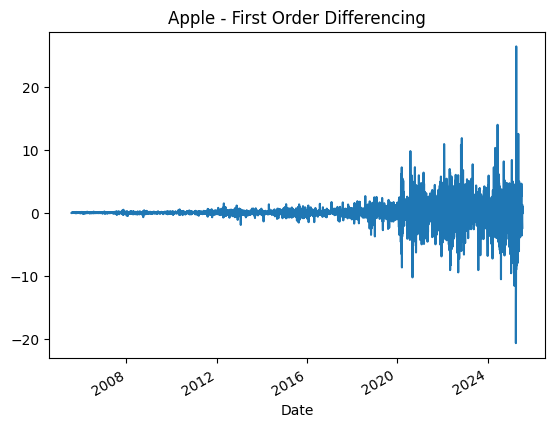

In [6]:
import matplotlib.pyplot as plt

# 1st order differencing
ts_diff = ts.diff().dropna()

# Plot the differenced data
ts_diff.plot(title="Apple - First Order Differencing")
plt.show()


In [7]:
from statsmodels.tsa.stattools import adfuller

# ADF test on differenced data
adf_result_diff = adfuller(ts_diff)
print("ADF Statistic:", adf_result_diff[0])
print("p-value:", adf_result_diff[1])
print("Critical Values:")
for key, value in adf_result_diff[4].items():
    print(f"   {key}: {value}")

if adf_result_diff[1] <= 0.05:
    print("✅ Differenced data is stationary.")
else:
    print("❌ Differenced data is still non-stationary.")


ADF Statistic: -13.567893302377446
p-value: 2.244182138105837e-25
Critical Values:
   1%: -3.43165984259144
   5%: -2.8621188086591505
   10%: -2.5670781005730454
✅ Differenced data is stationary.


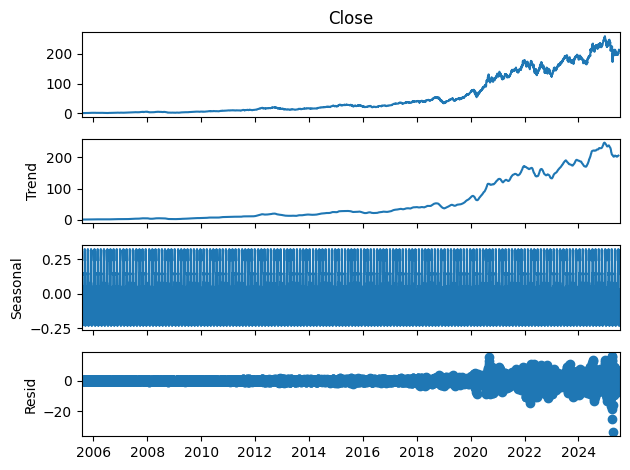

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal decomposition (assume daily data, set period=30 if monthly cycle, etc.)
decomposition = seasonal_decompose(ts, model='additive', period=30)
decomposition.plot()
plt.show()


In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA model (basic parameters)
sarima_model = SARIMAX(ts, 
                order=(1,1,1),        # (p,d,q)
                seasonal_order=(1,1,1,7),  # (P,D,Q,s) - assuming weely seasonality
                enforce_stationarity=False,
                enforce_invertibility=False)

sarima_model_fit = sarima_model.fit()

# Summary of the model
print(results.summary())


C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             Close   No. Observations:                 5028
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -9478.258
Date:                           Wed, 23 Jul 2025   AIC                          18966.517
Time:                                   16:58:04   BIC                          18999.114
Sample:                                        0   HQIC                         18977.940
                                          - 5028                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1518     15.710      0.010      0.992     -30.640      30.943
ma.L1         -0.1516     15.711     -0.010

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


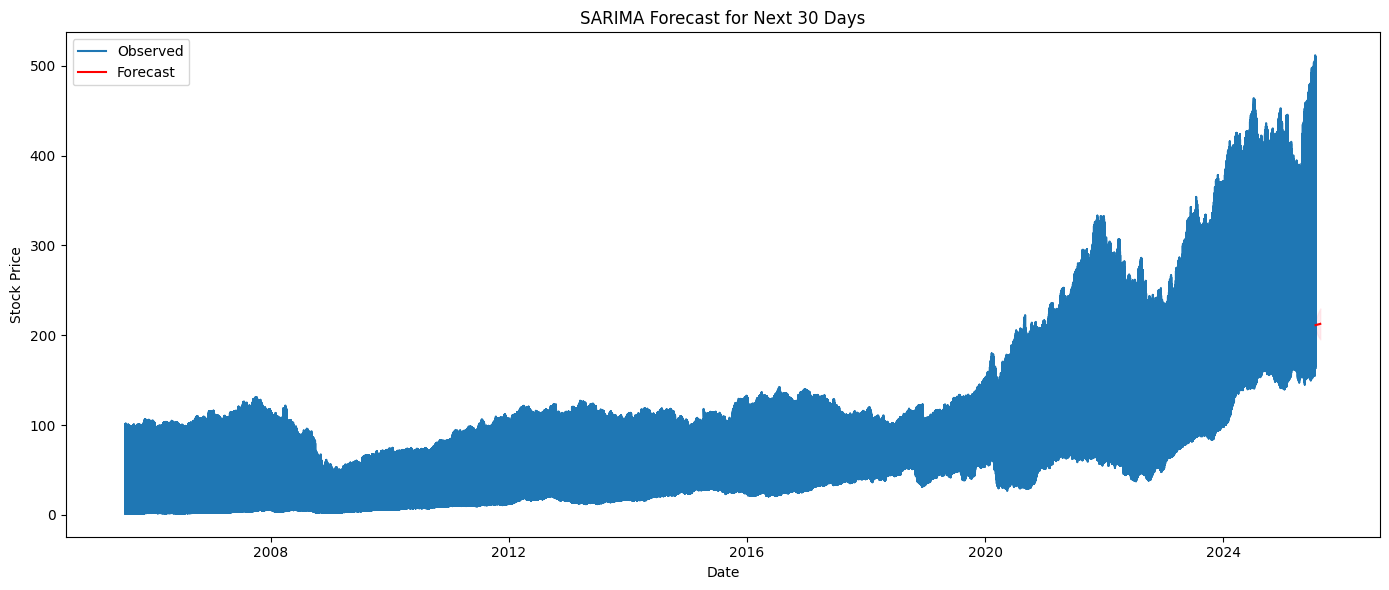

In [12]:
# Forecast the next 30 time steps
n_steps = 30
forecast = sarima_model_fit.get_forecast(steps=n_steps)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Plot forecast
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'], label='Observed')
plt.plot(pd.date_range(start=df.index[-1], periods=n_steps+1, freq='D')[1:], forecast_mean, color='red', label='Forecast')
plt.fill_between(pd.date_range(start=df.index[-1], periods=n_steps+1, freq='D')[1:], conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.title("SARIMA Forecast for Next 30 Days")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
!pip install pmdarima



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from pmdarima import auto_arima


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [19]:
!pip install numpy==1.24.4
!pip install pmdarima==2.0.3


  Using cached numpy-1.24.4.tar.gz (10.9 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [33 lines of output]
  Traceback (most recent call last):
    File "C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
      main()
    File "C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
      json_out['return_val'] = hook(**hook_input['kwargs'])
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 112, in get_requires_for_build_wheel
      backend = _build_backend()
                ^^^^^^^^^^^^^^^^
    File "C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_p

  Using cached pmdarima-2.0.3.tar.gz (630 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build pmdarima


  error: subprocess-exited-with-error
  
  exit code: 1
  
  [41 lines of output]
  <string>:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  Partial import of pmdarima during the build process.
  
  Traceback (most recent call last):
    File "<string>", line 190, in check_package_status
    File "C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py", line 90, in import_module
      return _bootstrap._gcd_import(name[level:], package, level)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
    File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
    File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
  ModuleNotFoundError: No module named 'nump